In [1]:
import sys
if 'google.colab' in sys.modules:
    %pip install botorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.0/6.0 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 291.2/291.2 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 10.9 MB/s eta 0:00:00


In [2]:
import os
import time
from contextlib import ExitStack

import gpytorch
import gpytorch.settings as gpts
import torch
from gpytorch.constraints import Interval
from gpytorch.distributions import MultivariateNormal
from gpytorch.kernels import RBFKernel, RFFKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.mlls import ExactMarginalLogLikelihood
from torch.quasirandom import SobolEngine
from torch import Tensor

from botorch.fit import fit_gpytorch_mll
from botorch.generation import MaxPosteriorSampling
from botorch.models import SingleTaskGP
from botorch.test_functions import Hartmann
from botorch.utils.sampling import draw_sobol_samples
from botorch.sampling.pathwise.posterior_samplers import get_matheron_path_model

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.double
SMOKE_TEST = os.environ.get("SMOKE_TEST")

In [3]:
hart6 = Hartmann(dim=6, negate=True).to(device=device, dtype=dtype)
dim = hart6.dim

In [20]:
def diversity_filter(
    X_pool: Tensor,
    batch_size: int,
    min_dist: float = 0.05,
) -> Tensor:

    selected = []

    for x in X_pool:
        if len(selected) == 0:
            selected.append(x)
        else:
            selected_tensor = torch.stack(selected)
            dists = torch.norm(selected_tensor - x, dim=1)
            if dists.min() > min_dist:
                selected.append(x)

        if len(selected) == batch_size:
            return torch.stack(selected)

In [21]:
def generate_batch(
    X: Tensor,
    Y: Tensor,
    batch_size: int,
    pool_size: int,
    n_candidates: int,
    seed: int,
) -> Tensor:
    assert X.min() >= 0.0 and X.max() <= 1.0 and torch.all(torch.isfinite(Y))
    assert pool_size >= batch_size

    base_kernel = RBFKernel(ard_num_dims=X.shape[-1])
    covar_module = ScaleKernel(base_kernel)

    model = SingleTaskGP(train_X=X, train_Y=Y, covar_module=covar_module)
    mll = ExactMarginalLogLikelihood(model.likelihood, model)

    fit_gpytorch_mll(mll)

    X_cand = draw_sobol_samples(bounds=hart6.bounds, n=n_candidates, q=1, seed=seed).squeeze(-2)

    with ExitStack() as es:
          es.enter_context(gpts.max_cholesky_size(float("inf")))
          es.enter_context(torch.no_grad())

          thompson_sampling = MaxPosteriorSampling(model=model, replacement=False)
          X_pool = thompson_sampling(X_cand, num_samples=pool_size)
          X_next = diversity_filter(X_pool, batch_size)

    return X_next


In [22]:
def run_optimization(
    n_candidates: int,
    n_init: int,
    max_evals: int,
    batch_size: int,
    seed: int,
) -> tuple[Tensor, Tensor]:
    X = draw_sobol_samples(bounds=hart6.bounds, n=n_init, q=1, seed=seed).squeeze(-2)
    Y = torch.tensor(
        [hart6(x) for x in X], dtype=dtype, device=device
    ).unsqueeze(-1)
    print(f"{len(X)}) Best value: {Y.max().item():.2e}")

    inner_seed = seed
    while len(X) < max_evals:
        # Create a batch
        start = time.monotonic()
        inner_seed += 1

        current_batch_size = min(batch_size, max_evals - len(X))
        print(f"Generating batch of size {current_batch_size}")

        X_next = generate_batch(
            X=X,
            Y=Y,
            batch_size=current_batch_size,
            pool_size=5*batch_size,
            n_candidates=n_candidates,
            seed=inner_seed,
        )
        end = time.monotonic()
        print(f"Generated batch in {end - start:.1f} seconds")
        Y_next = torch.tensor(
            [hart6(x) for x in X_next], dtype=dtype, device=device
        ).unsqueeze(-1)

        # Append data
        X = torch.cat((X, X_next), dim=0)
        Y = torch.cat((Y, Y_next), dim=0)

        print(f"{len(X)}) Best value: {Y.max().item():.2e}")
    return X, Y


In [23]:
batch_size = 5
n_init = 10
max_evals = 50
seed = 12345  # To get the same Sobol points
N_CAND = 10_000 if not SMOKE_TEST else 10

shared_args = {
    "n_candidates": N_CAND,
    "n_init": n_init,
    "max_evals": max_evals,
    "batch_size": batch_size,
    "seed": seed,
}

In [24]:
#!pip install memory_profiler
%load_ext memory_profiler

The memory_profiler extension is already loaded. To reload it, use:
  %reload_ext memory_profiler


In [25]:
%memit X_chol, Y_chol = run_optimization(**shared_args)

10) Best value: 6.72e-01
Generating batch of size 5


/usr/local/lib/python3.12/dist-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


Generated batch in 29.6 seconds
15) Best value: 6.72e-01
Generating batch of size 5


/usr/local/lib/python3.12/dist-packages/linear_operator/utils/cholesky.py:41: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


Generated batch in 26.6 seconds
20) Best value: 6.72e-01
Generating batch of size 5
Generated batch in 21.1 seconds
25) Best value: 7.32e-01
Generating batch of size 5
Generated batch in 18.2 seconds
30) Best value: 1.56e+00
Generating batch of size 5
Generated batch in 19.3 seconds
35) Best value: 1.84e+00
Generating batch of size 5
Generated batch in 17.9 seconds
40) Best value: 2.36e+00
Generating batch of size 5
Generated batch in 18.4 seconds
45) Best value: 2.78e+00
Generating batch of size 5
Generated batch in 18.3 seconds
50) Best value: 2.78e+00
peak memory: 6831.66 MiB, increment: 6199.19 MiB


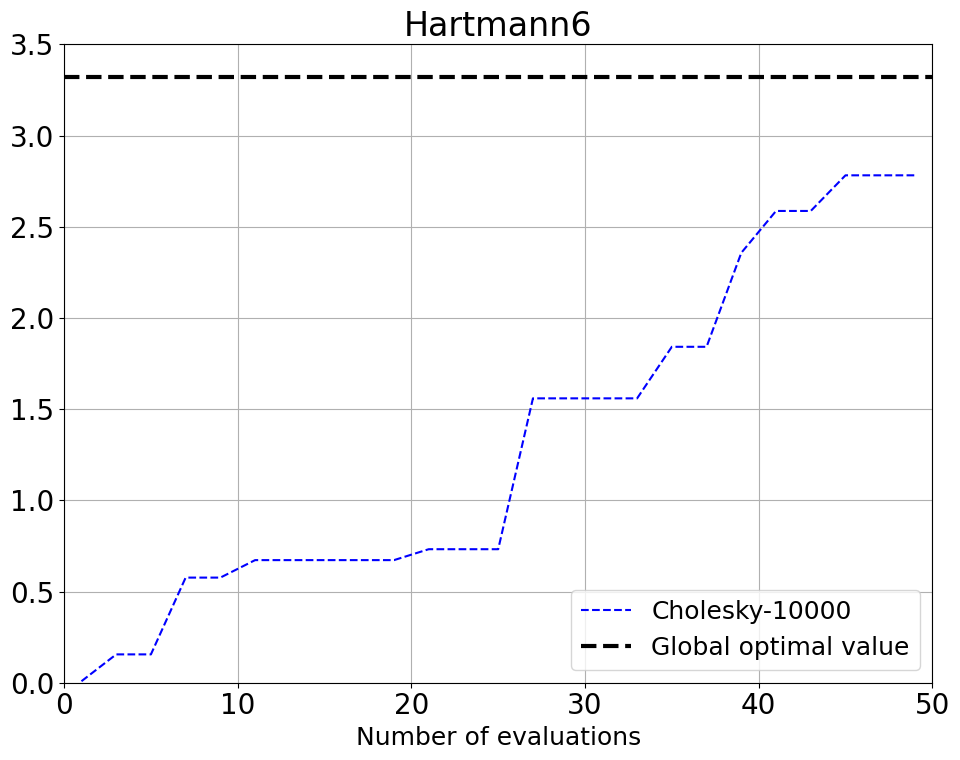

In [26]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np


fig = plt.figure(figsize=(10, 8))
matplotlib.rcParams.update({"font.size": 20})

results = [
    (Y_chol.cpu(), f"Cholesky-{N_CAND}", "b", "", 14, "--"),
]

optimum = hart6.optimal_value

ax = fig.add_subplot(1, 1, 1)
names = []
for res, name, c, m, ms, ls in results:
    names.append(name)
    fx = res.cummax(dim=0)[0]
    t = 1 + np.arange(len(fx))
    plt.plot(t[0::2], fx[0::2], c=c, marker=m, linestyle=ls, markersize=ms)

plt.plot([0, max_evals], [hart6.optimal_value, hart6.optimal_value], "k--", lw=3)
plt.xlabel("Function value", fontsize=18)
plt.xlabel("Number of evaluations", fontsize=18)
plt.title("Hartmann6", fontsize=24)
plt.xlim([0, max_evals])
plt.ylim([0, 3.5])

plt.grid(True)
plt.tight_layout()
plt.legend(
    names + ["Global optimal value"],
    loc="lower right",
    ncol=1,
    fontsize=18,
)
plt.show()

